In [1]:
# Goal: How well can ESM embeddings predict fitness scores for missense mutations?
import torch
import pandas as pd
import numpy as np

In [2]:
from transformers import AutoTokenizer, AutoModel

# https://huggingface.co/facebook/esm2_t6_8M_UR50D
esm_model_variant = 'facebook/esm2_t6_8M_UR50D'
tokenizer = AutoTokenizer.from_pretrained(esm_model_variant)
esm_model = AutoModel.from_pretrained(esm_model_variant)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█| 107/107 [00:00<00:00, 1910.16it/s, Materializing param=encoder.laye
EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSIN

In [3]:
csv_path = 'data/ARGR_ECOLI_Tsuboyama_2023_1AOY.csv'
df = pd.read_csv(csv_path)

In [42]:
# Reconstruct the wildtype sequence from the first mutation
first_mut = df['mutant'][0]
idx = int(first_mut[1:-1]) - 1
change_to = first_mut[0]
first_mut_seq = df['mutated_sequence'][0]
orig_seq = first_mut_seq[:idx] + change_to + first_mut_seq[idx+1:]
assert len(orig_seq) == len(first_mut_seq)

In [45]:
# dict with keys 'input_ids' and 'attention_mask'. 'input_ids' is a list of lists, with each list
# corresponding to a token sequence
sequences = np.array(df['mutated_sequence'])
tokens = tokenizer(list(sequences))
wt_token = tokenizer(orig_seq)

In [51]:
inputs = torch.tensor(tokens['input_ids'])
attn_masks = torch.tensor(tokens['attention_mask'])

wt_input = torch.tensor([wt_token['input_ids']])
wt_attn = torch.tensor([wt_token['attention_mask']])
# Now run the model on the tokens
esm_model.eval()
with torch.no_grad():
    # This has dimension [num_mutations, num_tokens, emb_dim_per_token]
    outputs = esm_model(input_ids=inputs, attention_mask=attn_masks)
    wt_emb = esm_model(input_ids=wt_input, attention_mask=wt_attn)
    print(outputs.last_hidden_state.shape)

torch.Size([1287, 71, 320])


In [116]:
df

,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,A10C,QEELVKAFKCLLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.612124,0
1,A10D,QEELVKAFKDLLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.330434,1
2,A10E,QEELVKAFKELLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.213194,1
3,A10F,QEELVKAFKFLLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.371293,1
4,A10G,QEELVKAFKGLLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.312110,1
...,...,...,...,...
1282,Y61R,QEELVKAFKALLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-2.526717,0
1283,Y61S,QEELVKAFKALLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-2.541252,0
1284,Y61T,QEELVKAFKALLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-2.312478,0
1285,Y61V,QEELVKAFKALLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-2.025066,0


In [53]:
full_emb = outputs.last_hidden_state.numpy()
wt_emb = wt_emb.last_hidden_state.numpy()
wt_mean = np.mean(wt_emb, axis=1)
mean_emb_per_mutation = np.mean(full_emb, axis=1)
delta_emb = mean_emb_per_mutation - wt_mean

In [57]:
fitness_labels = np.array(df['DMS_score'])
fitness_labels.shape, delta_emb.shape

((1287,), (1287, 320))

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(delta_emb, fitness_labels, test_size=0.3)

In [60]:
# Are the embeddings interpretable
# We will try 3 modeling techniques, which will help us understand how much and what type of signal
# the embeddings provide for this problem.
# 1) Ridge regression: Linear regression with L2 regularization. If this performs well it suggests that
#    phenotype is linearly related to embeddings
# 2) PCA + clustering: Examine the unsupervised structure to see if the embedding space can be partitioned
#    in a meaningful way relative to fitness.
# 3) Small MLP: If an MLP outperforms ridge regression, it is a sign that the mapping from embedding --> phenotypes 
#    includes non-linear interactions between embedding dimensions.
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, fit_intercept=True)
ridge.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [61]:
pred_fitness = ridge.predict(X_test)

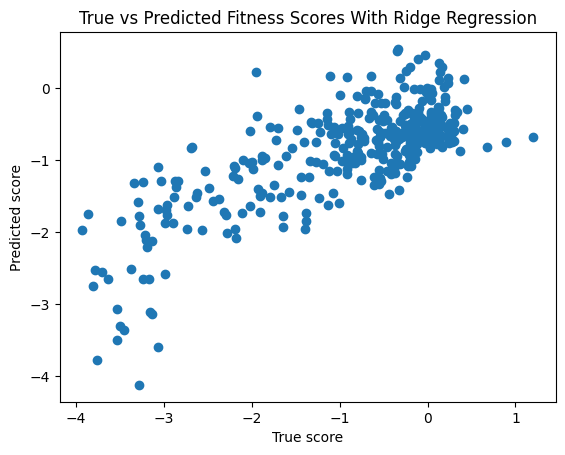

(SignificanceResult(statistic=np.float64(0.6325874976035286), pvalue=np.float64(1.1939667208431816e-44)),
 PearsonRResult(statistic=np.float64(0.7652889712591233), pvalue=np.float64(1.1589190194674275e-75)))

In [133]:
from scipy.stats import spearmanr, pearsonr

plt.figure()
plt.scatter(y_test, pred_fitness)
plt.xlabel("True score")
plt.ylabel("Predicted score")
plt.title("True vs Predicted Fitness Scores With Ridge Regression")
plt.savefig('figures/ridge_scores.png')
plt.show()

sr = spearmanr(y_test, pred_fitness)
pr = pearsonr(y_test, pred_fitness)
sr, pr

In [83]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
# 3 dimensionality reduction techniques
# PCA is linear, deterministic, finds the directions of greatest variance
pca = PCA(n_components=8)
emb_2d = pca.fit_transform(delta_emb)

print(emb_2d.shape)
kmeans = KMeans(n_clusters=4, random_state=4)
labels=kmeans.fit_predict(emb_2d)

(1287, 8)


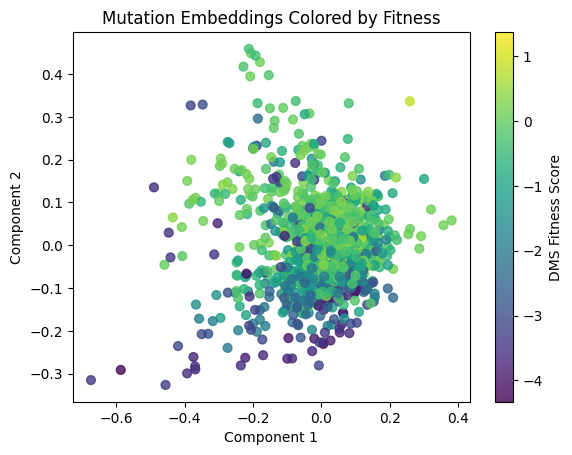

SignificanceResult(statistic=np.float64(0.4231079173942112), pvalue=np.float64(4.7642497598010354e-57))


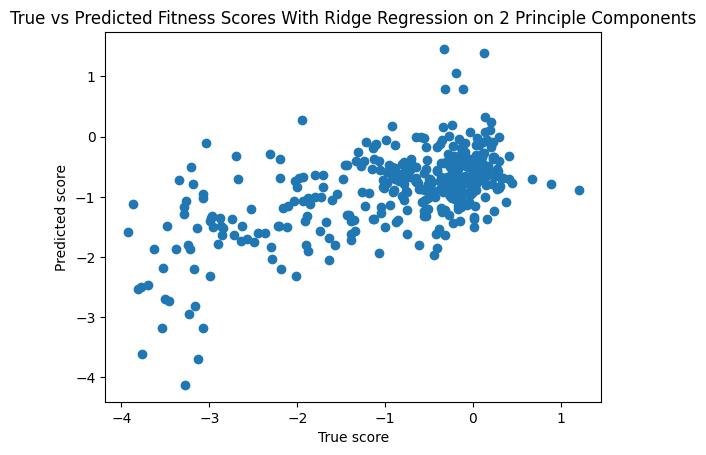

SignificanceResult(statistic=np.float64(0.48224602889678675), pvalue=np.float64(6.2079753795999105e-24)) PearsonRResult(statistic=np.float64(0.5912761637979542), pvalue=np.float64(7.436391049312216e-38))


In [132]:
from matplotlib import pyplot as plt
import seaborn as sns
dms_score = np.array(df['DMS_score'])
plt.figure()
scatter = plt.scatter(x=emb_2d[:, 0], y=emb_2d[:, 1], c=dms_score, cmap="viridis", s=40, alpha=0.8)
plt.colorbar(scatter, label="DMS Fitness Score")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Mutation Embeddings Colored by Fitness")
plt.savefig('figures/pca_two_components.png')
plt.show()

print(spearmanr(emb_2d[:, 1], dms_score))

train_emb_2d = pca.fit_transform(X_train)
test_emb_2d = pca.fit_transform(X_test)

# Run a Ridge regression using only the first 4 principal components
ridge_pca = Ridge(alpha=1.0, fit_intercept=True)
ridge_pca.fit(train_emb_2d[:, :4], y_train)
pred_ridge_pca = ridge_pca.predict(test_emb_2d[:, :4])
sr_pca = spearmanr(y_test, pred_ridge_pca)
pr_pca = pearsonr(y_test, pred_ridge_pca)

plt.figure()
plt.scatter(y_test, pred_ridge_pca)
plt.xlabel("True score")
plt.ylabel("Predicted score")
plt.title("True vs Predicted Fitness Scores With Ridge Regression on 2 Principle Components")
plt.savefig('figures/pca_ridge_scores.png')
plt.show()
print(sr_pca, pr_pca)

Test set
SignificanceResult(statistic=np.float64(0.8283832482611866), pvalue=np.float64(6.178245351376121e-99)) PearsonRResult(statistic=np.float64(0.8861189330296043), pvalue=np.float64(1.1887625735070183e-130))
Train set
SignificanceResult(statistic=np.float64(0.8837414367178232), pvalue=np.float64(2.1831498633267897e-298)) PearsonRResult(statistic=np.float64(0.9469570213968456), pvalue=np.float64(0.0))


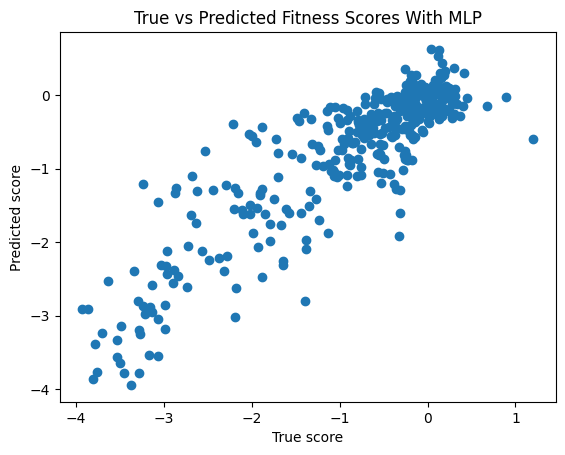

In [131]:
from sklearn.neural_network import MLPRegressor
mlp = MLPRegressor(hidden_layer_sizes=(16, 16), random_state=4, batch_size=8, max_iter=200, early_stopping=True, 
                   validation_fraction=0.1, n_iter_no_change=5)
mlp.fit(X_train, y_train)

mlp_pred = mlp.predict(X_test)
mlp_pred_train = mlp.predict(X_train)
sr_mlp = spearmanr(y_test, mlp_pred)
pr_mlp = pearsonr(y_test, mlp_pred)
sr_mlp_train = spearmanr(y_train, mlp_pred_train)
pr_mlp_train = pearsonr(y_train, mlp_pred_train)
print("Test set")
print(sr_mlp, pr_mlp)
print("Train set")
print(sr_mlp_train, pr_mlp_train)

plt.figure()
plt.scatter(y_test, mlp_pred)
plt.xlabel("True score")
plt.ylabel("Predicted score")
plt.title("True vs Predicted Fitness Scores With MLP")
#plt.show()
plt.savefig('figures/mlp_scores.png')

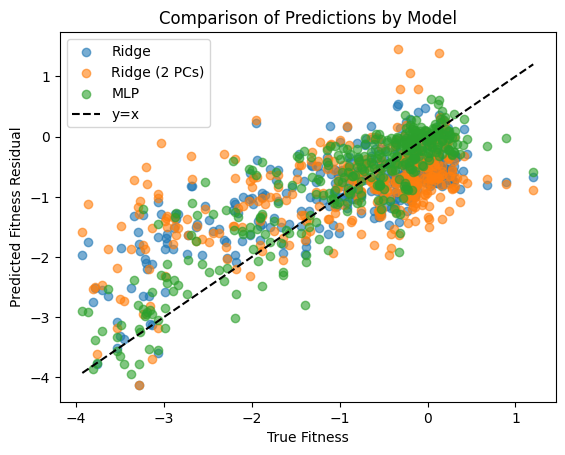

In [134]:
plt.figure()
plt.scatter(y_test, pred_fitness, label='Ridge', alpha=0.6)
plt.scatter(y_test, pred_ridge_pca, label='Ridge (2 PCs)', alpha=0.6)
plt.scatter(y_test, mlp_pred, label='MLP', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', label='y=x')
#plt.axhline(0, color='k', linestyle='--')

plt.xlabel('True Fitness')
plt.ylabel('Predicted Fitness Residual')
plt.legend()
plt.title('Comparison of Predictions by Model')
#plt.show()
plt.savefig('figures/summary_scores.png')